# Data Processing Part

In [1]:
import csv
import json
from datetime import datetime
import os
import sys


##### 1.    Read in the provided ACW Data using the CSV library.

In [2]:
# 1. Read in the provided ACW Data using the CSV library
def read_csv(file_path):       
    with open(file_path, mode='r') as file:   # Open the file in read mode
        reader = csv.DictReader(file)         # Create a CSV DictReader object to read the CSV data into a dictionary format
        data = list(reader)                   # Convert the reader object into a list
    return data                               # Return the data

# 1. Read data
file_path = os.path.join(os.getcwd(), 'acw_user_data.csv')  # Define the file path relative to the current working directory
data = read_csv(file_path)                                  # Read the data from the CSV file by calling the read_csv function


##### 2. As a CSV file is an entirely flat file structure, we need to convert our data back into its rich structure. Convert all flat structures into nested structures. These are notably:

        a. Vehicle - consists of make, model, year, and type
        b. Credit Card - consists of start date, end date, number, security code, and IBAN.
        c. Address - consists of the main address, city, and postcode.

For this task, it may be worthwhile inspecting the CSV headers to see which data columns may correspond to these above.
Note: Ensure that the values read in are appropriately cast to their respective types.

In [3]:
# 2. Convert flat structures into nested structures
def convert_to_nested_structures(data):
    processed_data = []

    # Loop through each row of the data to convert flat structures into nested structures
    for row in data:
        # 2a. Vehicle Information
        vehicle = {
            'make': row['Vehicle Make'],  # Extract vehicle make
            'model': row['Vehicle Model'],  # Extract vehicle model
            'year': int(row['Vehicle Year']) if row['Vehicle Year'].isdigit() else None,  # Convert to int or None if invalid
            'type': row['Vehicle Type']  # Extract vehicle type
        }

        # 2b. Credit Card Information
        credit_card = {
            'start_date': row['Credit Card Start Date'],  # Extract start date
            'expiry_date': row['Credit Card Expiry Date'],  # Extract expiry date
            'number': row['Credit Card Number'],  # Extract card number
            'security_code': row['Credit Card CVV'],  # Extract security code
            'iban': row.get('Bank IBAN', None)  # Extract IBAN (using .get to handle missing values)
        }

        # 2c. Address Information
        address = {
            'address': row['Address Street'],  # Extract street address
            'city': row['Address City'],  # Extract city
            'postcode': row['Address Postcode']  # Extract postcode
        }

        # 2d. Combine all fields into a single dictionary for the row
        processed_row = {
            'first_name': row['First Name'],  # Extract first name
            'last_name': row['Last Name'],  # Extract last name
            'age': int(row['Age (Years)']),  # Convert age to integer
            'vehicle': vehicle,  # Nested vehicle structure
            'credit_card': credit_card,  # Nested credit card structure
            'address': address,  # Nested address structure
            'dependants': row['Dependants'] if row['Dependants'] else 'Unknown',  # Handle missing dependants
            'marital_status': row['Marital Status'],  # Extract marital status
            'retired': row['Retired'] == 'TRUE',  # Convert to boolean
            'employer': row['Employer Company'] if row['Employer Company'] and row['Employer Company'] != 'N/A' else None,  # Handle missing employer
            'salary': float(row['Yearly Salary (Dollar)']) if row['Yearly Salary (Dollar)'].replace('.', '', 1).isdigit() else 0.0,  
            # Handle missing or invalid salary
            'sex': row['Sex']  # Extract sex
        }

        # Append the processed row to the final list
        processed_data.append(processed_row)

    return processed_data

# Example usage of the function
nested_data = convert_to_nested_structures(data)


##### 3.     The client informs you that they have had difficulty with errors in the dependants column. Some entries are empty (i.e. “ “ or “”), which may hinder your conversion from Task 2. These should be changed into something meaningful when encountered.
       Print a list where all such error corrections take place.
       E.g. Problematic rows for dependants: [16, 58, 80, 98]

In [4]:
# Read in the provided ACW Data using the CSV library with try-except for error handling
def read_csv(file_path):
    try:
        # Attempt to open the file and read it
        with open(file_path, mode='r') as file:
            reader = csv.DictReader(file)
            data = list(reader)  # Convert the reader into a list of dictionaries
            headers = reader.fieldnames  # Get the column headers
            return headers, data  # Return headers and data
    except FileNotFoundError:
        # Handle the case where the file is not found
        print(f"Error: File '{file_path}' not found.")
        return [], []  # Return empty lists if file is not found
    except Exception as e:
        # Handle any other exceptions
        print(f"Error reading CSV file: {e}")
        return [], []  # Return empty lists in case of other errors

# 2. Handle errors in the dependants column and print problematic rows (row numbers)
def handle_dependants_errors(data):
    problematic_rows = []  # List to track rows with issues

    # Loop through each row in the data
    for index, row in enumerate(data):
        try:
            # Get dependants value, default to None if key is missing
            dependants = row.get('Dependants', None)

            # Check for None, empty string, or space-only string
            if dependants is None or (isinstance(dependants, str) and dependants.strip() == ""):
                row['Dependants'] = '0'  # Change to a meaningful default value, e.g., '0'
                problematic_rows.append(index)  # Add the row index to the list of problematic rows
            # Handle non-string types (e.g., if dependants is a number or other type)
            elif not isinstance(dependants, str):
                row['Dependants'] = '0'  # Set to '0' if it's not a string
                problematic_rows.append(index)
            else:
                try:
                    # Attempt to convert the dependants value to an integer (if it's a string)
                    row['Dependants'] = str(int(dependants))
                except ValueError:
                    # If conversion fails, set to '0'
                    row['Dependants'] = '0'
                    problematic_rows.append(index)
        except Exception as e:
            # Handle any unexpected errors
            row['Dependants'] = '0'  # Set dependants to '0' in case of an error
            problematic_rows.append(index)  # Track this row as problematic

    # Print problematic rows in the specified format
    print(f"Problematic rows for dependants: {problematic_rows}")
    return problematic_rows

# 3. Corrected execution: Provide file path and apply functions
file_path = os.path.join(os.getcwd(), 'acw_user_data.csv')

# Read data from the CSV file
headers, data = read_csv(file_path)

# Handle errors in the 'Dependants' column
problematic_rows = handle_dependants_errors(data)


Problematic rows for dependants: [21, 109, 179, 205, 270, 272, 274, 358, 460, 468, 579, 636, 679, 725, 822, 865, 917, 931, 983]


##### 4. Write all records to a processed.json file in the JSON data format shown in the appendix to this document. This should be a list of dictionaries, where each index of the list is a dictionary representing a singular person.

In [5]:
# 4. Write processed data to JSON
def write_json(data, output_file):
    try:
        with open(output_file, 'w') as json_file:
            json.dump(data, json_file, indent=4)  # Write data to JSON with indentation
        print(f"Data successfully written to {output_file}")
    except Exception as e:
        print(f"Error writing to JSON file: {e}")

# Common file path for the JSON output
output_json_path = os.path.join(os.getcwd(), 'processed.json')

# Assuming `nested_data` is the processed data you want to save
write_json(nested_data, output_json_path)


Data successfully written to E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\processed.json


##### 5. You should create two additional file outputs, retired.json and employed.json, these should contain all retired customers (as indicated by the retired field in the CSV), and all employed customers respectively (as indicated by the employer field in the CSV) and be in the JSON data format.

In [6]:
# Function to create retired and employed JSON files
def create_retired_and_employed(data):
    # Get the current directory (just the folder, not including the CSV file)
    current_directory = os.getcwd()
    
    # Filter out retired and employed people
    retired_data = [person for person in data if person['retired']]
    employed_data = [person for person in data if person['employer']]
    
    # Create the file paths for JSON output
    retired_file_path = os.path.join(current_directory, 'retired.json')
    employed_file_path = os.path.join(current_directory, 'employed.json')
    
    # Write the filtered data to respective JSON files
    write_json(retired_data, retired_file_path)
    write_json(employed_data, employed_file_path)

# Example usage:
create_retired_and_employed(nested_data)


Data successfully written to E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\retired.json
Data successfully written to E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\employed.json


##### 6.  The client states that there may be some issues with credit card entries. Any customers that have more than 10 years between their start and end date need writing to a separate file, called remove_ccard.json, in the JSON data format. The client will manually deal with these later based on your output. They request that you write a function to help perform this, which accepts a single row from the CSV data,and outputs whether the row should be flagged. This can then be used when determining whether to write the current person to the remove_ccard file. Note the dates are shown in the format used on credit cards which is “MM/YY”.

In [7]:
# Helper function to parse different date formats safely
def parse_date(date_str):
    # List of possible date formats
    possible_formats = ["%m/%y", "%y-%b", "%b-%y", "%m-%Y", "%Y-%m", "%d-%b-%y"]
    
    for fmt in possible_formats:
        try:
            return datetime.strptime(date_str, fmt)
        except ValueError:
            continue
    return None  # Return None if no valid format found

# Function to check credit card duration validity (more than 10 years between start and end date)
def check_credit_card_duration(data):
    problem_rows = []
    
    for person in data:
        start_date_str = person['credit_card']['start_date']
        expiry_date_str = person['credit_card']['expiry_date']
        
        start_date = parse_date(start_date_str)
        expiry_date = parse_date(expiry_date_str)
        
        # Skip if dates couldn't be parsed
        if not start_date or not expiry_date:
            continue
        
        # Calculate duration in years
        duration = (expiry_date - start_date).days / 365.25
        
        # If duration is more than 10 years, add to problem_rows
        if duration > 10:
            problem_rows.append(person)
    
    # Save output in current working directory
    output_file_path = os.path.join(os.getcwd(), 'remove_ccard.json')
    write_json(problem_rows, output_file_path)
    print(f"File saved: {output_file_path}")
    print(f"Total problematic cards found: {len(problem_rows)}")

# Example usage
check_credit_card_duration(nested_data)

Data successfully written to E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\remove_ccard.json
File saved: E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\remove_ccard.json
Total problematic cards found: 253


##### 7. You have been tasked with calculating some additional metrics which will be used for ranking customers. You should create a new data attribute for our customers called “Salary-Commute”. Reading in from processed.json:
    a. Add, and calculate appropriately, this new attribute. It should represent the Salary that a customer earns, per Km of their commute.
        i. Note: If a person travels 1 or fewer commute Km, then their salary-commute would be just their salary.
    b.Sort these records by that new metric, in ascending order.
    c.Store the output file out as a JSON format, for a commute.json file.

In [8]:
# Function to calculate salary-commute and sort by it
def calculate_salary_commute(data):
    for person in data:
        # Inspect the column name for commute distance and handle missing data
        commute = float(person['Distance Commuted to Work (Km)']) if 'Distance Commuted to Work (Km)' in person else 0
        if commute > 1:
            person['salary_commute'] = person['salary'] / commute
        else:
            person['salary_commute'] = person['salary']
    
    # Sort the data based on salary_commute in ascending order
    sorted_data = sorted(data, key=lambda x: x['salary_commute'])
    
    # Get the current directory of the Jupyter notebook
    current_directory = os.getcwd()
    
    # Define the path for the output file
    output_file_path = os.path.join(current_directory, 'commute.json')
    
    # Write the sorted data to the output JSON file
    write_json(sorted_data, output_file_path)

# Example usage: 
calculate_salary_commute(nested_data)


Data successfully written to E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\commute.json


In [9]:
# Function to output processed file paths in a clean format
def output_processed_files_paths():
    # Get the current directory of the Jupyter notebook
    current_directory = os.getcwd()
    
    # Define file names
    files = ['processed.json','retired.json', 'employed.json', 'remove_ccard.json', 'commute.json']
    
    # Create file paths for each file
    file_paths = [os.path.join(current_directory, file) for file in files]
    
    # Format the file paths nicely
    formatted_paths = "\n".join([f"- {path}" for path in file_paths])
    
    # Return the formatted paths
    return formatted_paths

# Example usage: 
processed_json_paths = output_processed_files_paths()
print("Processed Files Paths:")
print(processed_json_paths)

Processed Files Paths:
- E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\processed.json
- E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\retired.json
- E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\employed.json
- E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\remove_ccard.json
- E:\Hull Data Science\First Semester\Introduction to Python Programming\Assignment\Final Assignment\commute.json


# Data Visualization Part

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load the dataset (make sure to replace the file path accordingly)
file_path = r'acw_user_data.csv'
df = pd.read_csv(file_path)

# Obtain Salary and Age Data Series
salary = df['Yearly Salary (Dollar)']
age = df['Age (Years)']

# a. Mean Salary
mean_salary = salary.mean()
print(f"Mean Salary: {mean_salary}")

# b. Median Age
median_age = age.median()
print(f"Median Age: {median_age}")

Mean Salary: 57814.078
Median Age: 54.0


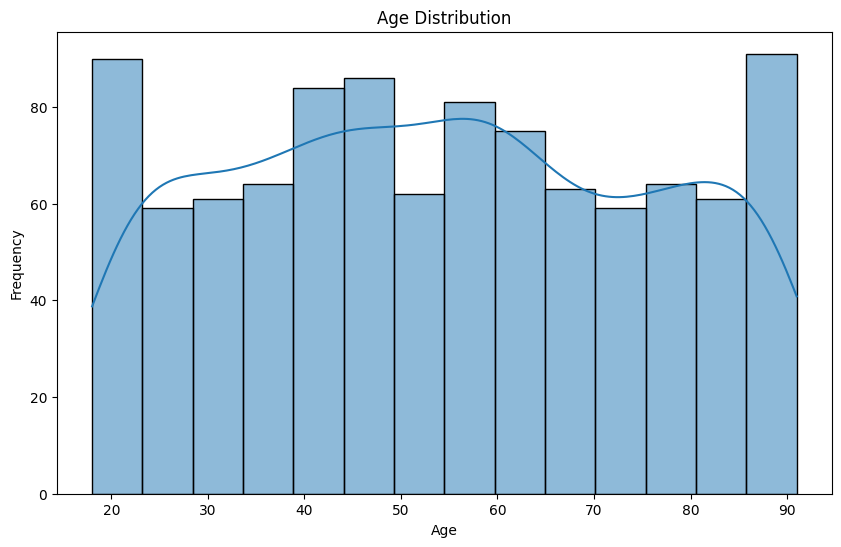

In [11]:
2. # a. Age: Calculate the number of bins with a bin width of 5
bin_width = 5
age_range = age.max() - age.min()
num_bins = int(age_range / bin_width)  # Calculate the number of bins

# Plotting Age with calculated bins
plt.figure(figsize=(10, 6))
sns.histplot(age, bins=num_bins, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Index(['Address Street', 'Address City', 'Address Postcode', 'Age (Years)',
       'Distance Commuted to Work (Km)', 'Employer Company',
       'Credit Card Start Date', 'Credit Card Expiry Date',
       'Credit Card Number', 'Credit Card CVV', 'Dependants', 'First Name',
       'Bank IBAN', 'Last Name', 'Marital Status', 'Yearly Pension (Dollar)',
       'Retired', 'Yearly Salary (Dollar)', 'Sex', 'Vehicle Make',
       'Vehicle Model', 'Vehicle Year', 'Vehicle Type'],
      dtype='object')


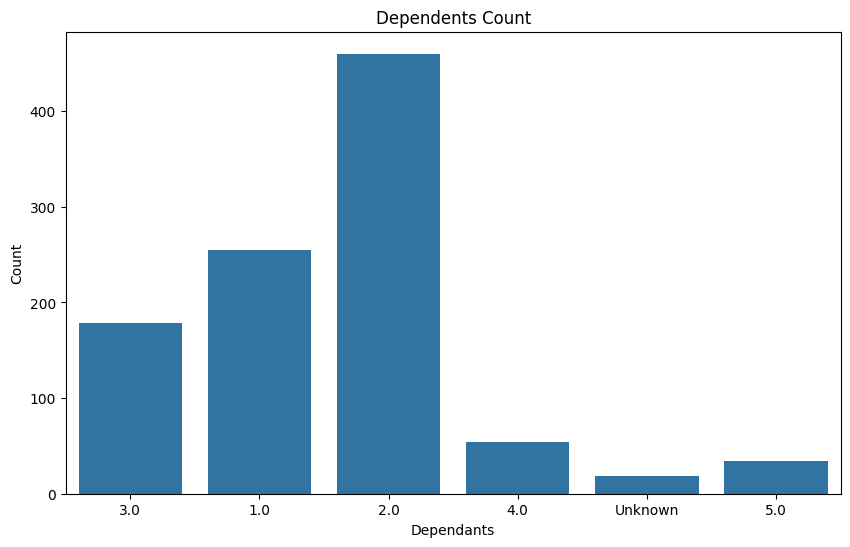

In [12]:
# b. Dependents: Replace missing or erroneous values using Seaborn
# Check the column names in the DataFrame
print(df.columns)

# Handle missing or erroneous dependants data (after confirming correct column name)
df['Dependants'] = df['Dependants'].apply(lambda x: 'Unknown' if pd.isnull(x) or str(x).strip() == '' else x)

# Plot Dependents
plt.figure(figsize=(10, 6))
sns.countplot(x='Dependants', data=df)
plt.title('Dependents Count')
plt.xlabel('Dependants')
plt.ylabel('Count')
plt.show()

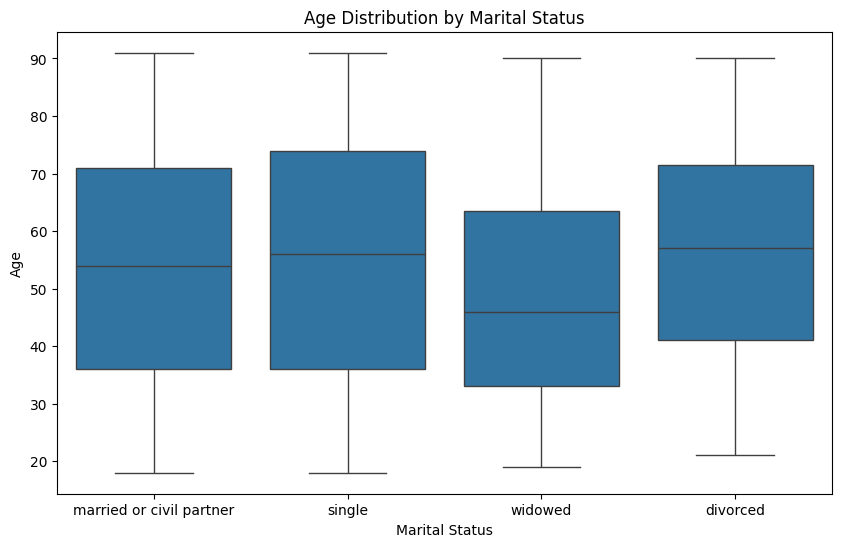

In [13]:
# c. Age conditioned on Marital Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Marital Status', y='Age (Years)', data=df)
plt.title('Age Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Age')
plt.show()

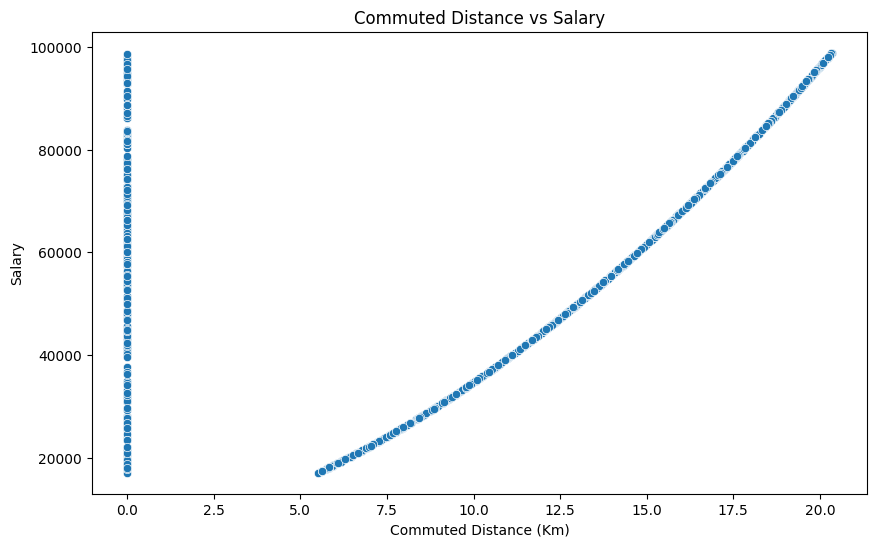

In [14]:
3. # a. Commuted Distance against Salary
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance Commuted to Work (Km)', y='Yearly Salary (Dollar)', data=df)
plt.title('Commuted Distance vs Salary')
plt.xlabel('Commuted Distance (Km)')
plt.ylabel('Salary')
plt.show()

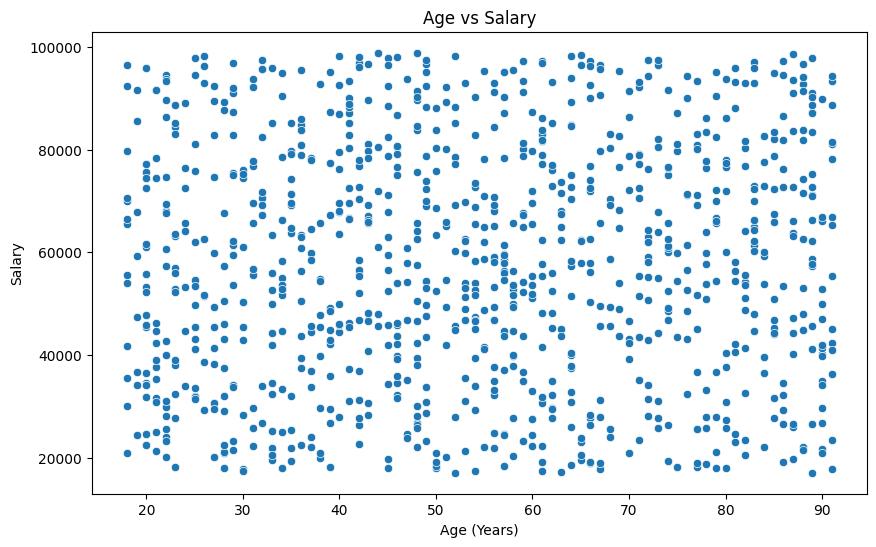

In [15]:
# b. Age against Salary
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age (Years)', y='Yearly Salary (Dollar)', data=df)
plt.title('Age vs Salary')
plt.xlabel('Age (Years)')
plt.ylabel('Salary')
plt.show()

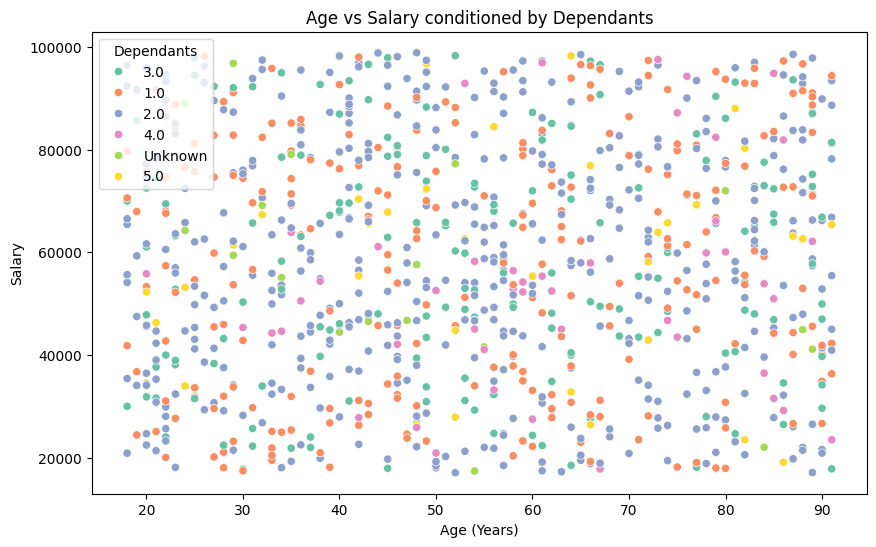

In [16]:
# c. Age against Salary conditioned by Dependants
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age (Years)', y='Yearly Salary (Dollar)', data=df, hue='Dependants', palette='Set2')
plt.title('Age vs Salary conditioned by Dependants')
plt.xlabel('Age (Years)')
plt.ylabel('Salary')
plt.show()

In [17]:
# Define the function to save the plot
def save_plot(plot_function, filename):
    plot_function()  # Generate the plot by calling the function
    plt.savefig(filename)  # Save the plot to the specified file
    plt.close()  # Close the plot to free up memory

# Example of saving the Age Distribution plot:
save_plot(lambda: sns.histplot(age, bins=num_bins, kde=True, color='skyblue'), 'age_distribution.png')
save_plot(lambda: sns.countplot(x='Dependants', data=df), 'dependants_count.png')
save_plot(lambda: sns.boxplot(x='Marital Status', y='Age (Years)', data=df), 'age_by_marital_status.png')
save_plot(lambda: sns.scatterplot(x='Distance Commuted to Work (Km)', y='Yearly Salary (Dollar)', data=df), 'commute_vs_salary.png')
save_plot(lambda: sns.scatterplot(x='Age (Years)', y='Yearly Salary (Dollar)', data=df), 'age_vs_salary.png')
save_plot(lambda: sns.scatterplot(x='Age (Years)', y='Yearly Salary (Dollar)', data=df, hue='Dependants', palette='Set2'), 'age_vs_salary_dependants.png')